In [ ]:
4CH


Epoch 1
Train Loss 1.2709 | Dice 0.1430 | Acc 0.2131
Val   Loss 1.2214 | Dice 0.1445 | Acc 0.2223


Epoch 2
Train Loss 1.2070 | Dice 0.1684 | Acc 0.2662
Val   Loss 1.1989 | Dice 0.1605 | Acc 0.2599


Epoch 3
Train Loss 1.1877 | Dice 0.1858 | Acc 0.2937
Val   Loss 1.1793 | Dice 0.1854 | Acc 0.2825


Epoch 4
Train Loss 1.1706 | Dice 0.2405 | Acc 0.3227
Val   Loss 1.1644 | Dice 0.2683 | Acc 0.3255


Epoch 5
Train Loss 1.1505 | Dice 0.2772 | Acc 0.3172
Val   Loss 1.1417 | Dice 0.2758 | Acc 0.2952


Epoch 6
Train Loss 1.1284 | Dice 0.2841 | Acc 0.2911
Val   Loss 1.1222 | Dice 0.2766 | Acc 0.2698


Epoch 7
Train Loss 1.1070 | Dice 0.2929 | Acc 0.2789
Val   Loss 1.1001 | Dice 0.3134 | Acc 0.2849


Epoch 8
Train Loss 1.0820 | Dice 0.2880 | Acc 0.2747
Val   Loss 1.0812 | Dice 0.2605 | Acc 0.2458


Epoch 9
Train Loss 1.0478 | Dice 0.2975 | Acc 0.2822
Val   Loss 1.0472 | Dice 0.3002 | Acc 0.2707


Epoch 10
Train Loss 1.0203 | Dice 0.3159 | Acc 0.2986
Val   Loss 1.0177 | Dice 0.3233 | Acc 0.3108


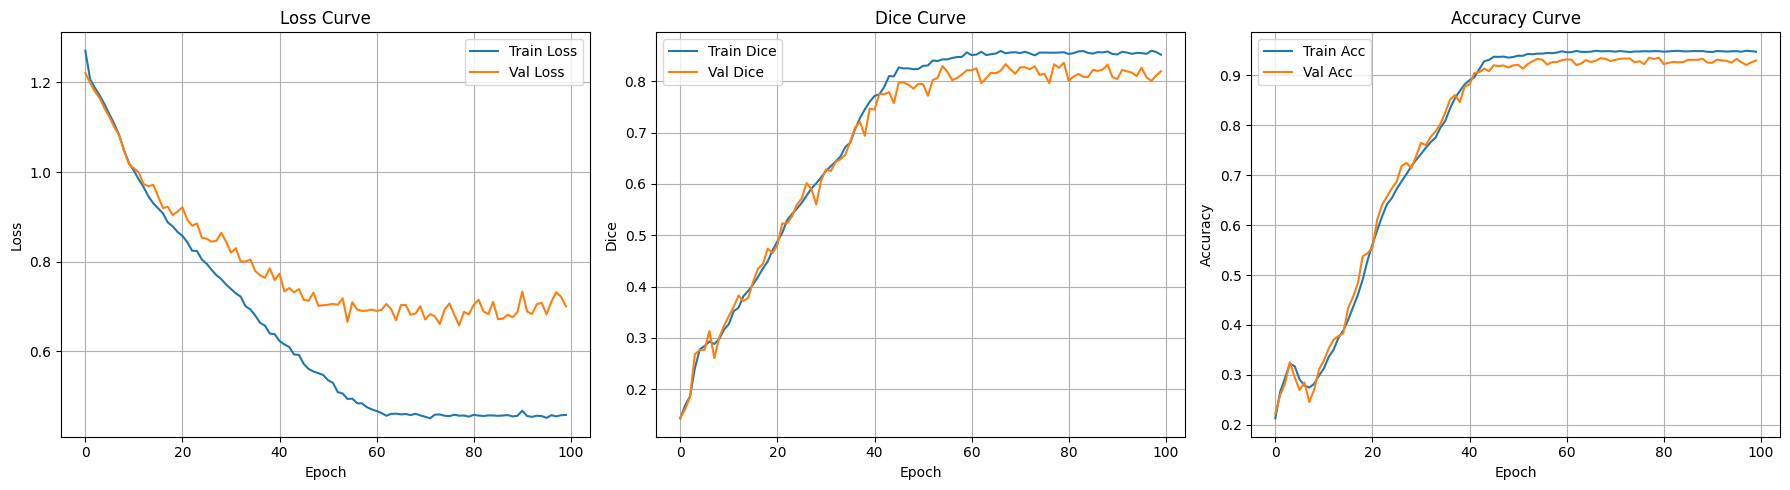

In [8]:
# ============================================
# 🔹 Imports
# ============================================

import os, gc, warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True


# ============================================
# 🔹 Paths
# ============================================

BASE_PATH = r"D:\CMR-MULTI\CINE_MULTI"

TRAIN_IMAGE_PATH = os.path.join(BASE_PATH,"4CH_TR","image")
TRAIN_MASK_PATH  = os.path.join(BASE_PATH,"4CH_TR","anno")

VAL_IMAGE_PATH   = os.path.join(BASE_PATH,"4CH_VAL","image")
VAL_MASK_PATH    = os.path.join(BASE_PATH,"4CH_VAL","anno")

NUM_CLASSES = 6
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================
# 🔹 Dataset (FIXED + FAST)
# ============================================

class NiftiDataset(Dataset):

    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        f = self.files[idx]

        img_nii = nib.load(os.path.join(self.img_dir, f)).dataobj
        mask_nii = nib.load(os.path.join(self.mask_dir, f)).dataobj

        depth = img_nii.shape[2]
        T = 15

        start = 0 if depth <= T else np.random.randint(0, depth - T)

        imgs, masks = [], []

        for i in range(start, start + T):

            img = np.array(img_nii[:, :, i], dtype=np.float32)
            mask = np.array(mask_nii[:, :, i], dtype=np.int64)

            if img.max() > img.min():
                img = (img - img.min()) / (img.max() - img.min())

            img = torch.tensor(img).unsqueeze(0)
            mask = torch.tensor(mask)

            img = F.interpolate(img.unsqueeze(0),(256,256),mode='bilinear').squeeze(0)
            mask = F.interpolate(mask.unsqueeze(0).unsqueeze(0).float(),
                                 (256,256),
                                 mode='nearest').squeeze().long()

            imgs.append(img)
            masks.append(mask)

        return torch.stack(imgs), torch.stack(masks)


# ============================================
# 🔹 SPLIT + DATALOADER (FIXED CRASH)
# ============================================

train_ds = NiftiDataset(TRAIN_IMAGE_PATH, TRAIN_MASK_PATH)
val_ds   = NiftiDataset(VAL_IMAGE_PATH, VAL_MASK_PATH)

train_size = int(0.75 * len(train_ds))
test_size  = len(train_ds) - train_size

train_data, test_data = random_split(train_ds,[train_size,test_size])


train_loader = DataLoader(
    train_data,
    batch_size=2,
    shuffle=True,
    num_workers=0,   
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=2,
    num_workers=0,   
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=2,
    num_workers=0
)


# ============================================
# 🔹 Model (UNCHANGED)
# ============================================

class ConvLSTMCell(nn.Module):
    def __init__(self,in_ch,hidden_ch):
        super().__init__()
        self.hidden_ch = hidden_ch
        self.conv = nn.Conv2d(in_ch+hidden_ch,4*hidden_ch,3,padding=1)

    def forward(self,x,state):
        h,c = state

        if h is None:
            b,_,h_,w_ = x.shape
            h = torch.zeros(b,self.hidden_ch,h_,w_,device=x.device)
            c = torch.zeros_like(h)

        gates = self.conv(torch.cat([x,h],dim=1))
        i,f,o,g = torch.chunk(gates,4,dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)

        c = f*c + i*g
        h = o*torch.tanh(c)

        return h,c

    def init_state(self,b,size):
        h = torch.zeros(b,self.hidden_ch,size[0],size[1],device=next(self.parameters()).device)
        c = torch.zeros_like(h)
        return h,c


class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.net(x)


class UNetConvLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1,32)
        self.enc2 = DoubleConv(32,64)
        self.enc3 = DoubleConv(64,128)

        self.pool = nn.MaxPool2d(2)

        self.lstm = ConvLSTMCell(128,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = DoubleConv(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = DoubleConv(64,32)

        self.out = nn.Conv2d(32,NUM_CLASSES,1)

    def forward(self,x):

        x = x.unsqueeze(1) if x.dim()==4 else x

        B,T,C,H,W = x.shape

        outs=[]
        h,c=None,None

        for t in range(T):

            xt = x[:,t]

            e1 = self.enc1(xt)
            e2 = self.enc2(self.pool(e1))
            e3 = self.enc3(self.pool(e2))

            if h is None:
                h,c = self.lstm.init_state(B,(e3.shape[2],e3.shape[3]))

            h,c = self.lstm(e3,(h,c))

            d2 = self.up2(h)
            d2 = self.dec2(torch.cat([d2,e2],dim=1))

            d1 = self.up1(d2)
            d1 = self.dec1(torch.cat([d1,e1],dim=1))

            outs.append(self.out(d1))

        return torch.stack(outs,dim=1)


# ============================================
# 🔹 LOSS
# ============================================

ce = nn.CrossEntropyLoss()

class DiceLoss(nn.Module):
    def forward(self,pred,target):

        B,T,H,W = target.shape

        pred = torch.softmax(pred,dim=2)

        pred = pred.view(B*T,NUM_CLASSES,H,W)
        target = target.view(B*T,H,W)

        target = F.one_hot(target,NUM_CLASSES).permute(0,3,1,2).float()

        inter = (pred*target).sum((2,3))
        union = pred.sum((2,3)) + target.sum((2,3))

        return 1 - ((2*inter+1e-6)/(union+1e-6)).mean()


def loss_fn(pred,target):
    return 0.5*ce(pred.view(-1,NUM_CLASSES),target.view(-1)) + 0.5*DiceLoss()(pred,target)


# ============================================
# 🔹 METRICS
# ============================================

def dice_score(pred,target):

    if pred.dim()==5:
        pred = torch.argmax(pred,dim=2)
    else:
        pred = torch.argmax(pred,dim=1)

    pred = pred.reshape(-1,pred.shape[-2],pred.shape[-1])
    target = target.reshape(-1,target.shape[-2],target.shape[-1])

    dice=0
    for c in range(NUM_CLASSES):
        p = (pred==c).float()
        t = (target==c).float()
        dice += (2*(p*t).sum()+1e-6)/(p.sum()+t.sum()+1e-6)

    return dice/NUM_CLASSES


def accuracy(pred,target):

    if pred.dim()==5:
        pred = torch.argmax(pred,dim=2)
    else:
        pred = torch.argmax(pred,dim=1)

    pred = pred.reshape(-1,pred.shape[-2],pred.shape[-1])
    target = target.reshape(-1,target.shape[-2],target.shape[-1])

    return (pred==target).float().mean()


# ============================================
# 🔥 MODEL + OPTIMIZER + SCHEDULER
# ============================================

model = UNetConvLSTM().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)


# ============================================
# 🔹 HISTORY (FIXED)
# ============================================

train_loss_l, val_loss_l = [], []
train_dice_l, val_dice_l = [], []
train_acc_l, val_acc_l = [], []


# ============================================
# 🔹 TRAIN LOOP
# ============================================

best = 0

for epoch in range(100):

    model.train()
    tl=td=ta=0

    for x,y in train_loader:
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out,y)
        loss.backward()
        optimizer.step()

        tl += loss.item()
        td += dice_score(out,y).item()
        ta += accuracy(out,y).item()

    model.eval()
    vl=vd=va=0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)

            out = model(x)
            loss = loss_fn(out,y)

            vl += loss.item()
            vd += dice_score(out,y).item()
            va += accuracy(out,y).item()

    tl/=len(train_loader); vl/=len(val_loader)
    td/=len(train_loader); vd/=len(val_loader)
    ta/=len(train_loader); va/=len(val_loader)

    scheduler.step(vl)

    train_loss_l.append(tl)
    val_loss_l.append(vl)
    train_dice_l.append(td)
    val_dice_l.append(vd)
    train_acc_l.append(ta)
    val_acc_l.append(va)

    print(f"""
Epoch {epoch+1}
Train Loss {tl:.4f} | Dice {td:.4f} | Acc {ta:.4f}
Val   Loss {vl:.4f} | Dice {vd:.4f} | Acc {va:.4f}
""")

    if vd > best:
        best = vd
        torch.save(model.state_dict(),"best_model2.pth")

    torch.save({
        "epoch":epoch,
        "model":model.state_dict(),
        "optimizer":optimizer.state_dict()
    },"checkpoint2.pth")


# ============================================
# 🔹 CLASSIFICATION REPORT
# ============================================

all_p,all_t=[],[]

model.eval()

with torch.no_grad():
    for x,y in test_loader:
        x=x.to(device)
        out=model(x)
        p=torch.argmax(out,dim=2)

        all_p.extend(p.cpu().reshape(-1).numpy())
        all_t.extend(y.reshape(-1).numpy())

print(classification_report(all_t,all_p,
      target_names=["BG","LV","MYO","RV","RA","LA"]))
# ============================================
# 🔹 PLOTS (Loss / Dice / Accuracy)
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))

# ---------------- LOSS ----------------
plt.subplot(1,3,1)
plt.plot(train_loss_l, label="Train Loss")
plt.plot(val_loss_l, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# ---------------- DICE ----------------
plt.subplot(1,3,2)
plt.plot(train_dice_l, label="Train Dice")
plt.plot(val_dice_l, label="Val Dice")
plt.title("Dice Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.grid()

# ---------------- ACC ----------------
plt.subplot(1,3,3)
plt.plot(train_acc_l, label="Train Acc")
plt.plot(val_acc_l, label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [18]:
# ============================================
# 🔹 TEST EVALUATION
# ============================================

model.load_state_dict(torch.load("best_model2.pth"))
model.eval()

test_loss = 0
test_dice = 0
test_acc  = 0

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        out = model(x)

        loss = loss_fn(out, y)

        test_loss += loss.item()
        test_dice += dice_score(out, y).item()
        test_acc  += accuracy(out, y).item()

n = len(test_loader)

test_loss /= n
test_dice /= n
test_acc  /= n

print("\n========== TEST RESULTS ==========")
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test Acc  : {test_acc:.4f}")


========== TEST RESULTS ==========
Test Loss : 0.6972
Test Dice : 0.8188
Test Acc  : 0.9346


In [5]:
# ============================================
# 🔹 Imports
# ============================================

import os, gc, warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True


# ============================================
# 🔹 Paths
# ============================================

BASE_PATH = r"D:\CMR-MULTI\CINE_MULTI"

TRAIN_IMAGE_PATH = os.path.join(BASE_PATH,"4CH_TR","image")
TRAIN_MASK_PATH  = os.path.join(BASE_PATH,"4CH_TR","anno")

VAL_IMAGE_PATH   = os.path.join(BASE_PATH,"4CH_VAL","image")
VAL_MASK_PATH    = os.path.join(BASE_PATH,"4CH_VAL","anno")

NUM_CLASSES = 6
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================
# 🔹 Dataset (FIXED + FAST)
# ============================================

class NiftiDataset(Dataset):

    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        f = self.files[idx]

        img_nii = nib.load(os.path.join(self.img_dir, f)).dataobj
        mask_nii = nib.load(os.path.join(self.mask_dir, f)).dataobj

        depth = img_nii.shape[2]
        T = 15

        start = 0 if depth <= T else np.random.randint(0, depth - T)

        imgs, masks = [], []

        for i in range(start, start + T):

            img = np.array(img_nii[:, :, i], dtype=np.float32)
            mask = np.array(mask_nii[:, :, i], dtype=np.int64)

            if img.max() > img.min():
                img = (img - img.min()) / (img.max() - img.min())

            img = torch.tensor(img).unsqueeze(0)
            mask = torch.tensor(mask)

            img = F.interpolate(img.unsqueeze(0),(256,256),mode='bilinear').squeeze(0)
            mask = F.interpolate(mask.unsqueeze(0).unsqueeze(0).float(),
                                 (256,256),
                                 mode='nearest').squeeze().long()

            imgs.append(img)
            masks.append(mask)

        return torch.stack(imgs), torch.stack(masks)


# ============================================
# 🔹 SPLIT + DATALOADER (FIXED CRASH)
# ============================================

train_ds = NiftiDataset(TRAIN_IMAGE_PATH, TRAIN_MASK_PATH)
val_ds   = NiftiDataset(VAL_IMAGE_PATH, VAL_MASK_PATH)

train_size = int(0.75 * len(train_ds))
test_size  = len(train_ds) - train_size

train_data, test_data = random_split(train_ds,[train_size,test_size])


train_loader = DataLoader(
    train_data,
    batch_size=2,
    shuffle=True,
    num_workers=0,   
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=2,
    num_workers=0,   
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=2,
    num_workers=0
)


# ============================================
# 🔹 Model (UNCHANGED)
# ============================================

class ConvLSTMCell(nn.Module):
    def __init__(self,in_ch,hidden_ch):
        super().__init__()
        self.hidden_ch = hidden_ch
        self.conv = nn.Conv2d(in_ch+hidden_ch,4*hidden_ch,3,padding=1)

    def forward(self,x,state):
        h,c = state

        if h is None:
            b,_,h_,w_ = x.shape
            h = torch.zeros(b,self.hidden_ch,h_,w_,device=x.device)
            c = torch.zeros_like(h)

        gates = self.conv(torch.cat([x,h],dim=1))
        i,f,o,g = torch.chunk(gates,4,dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)

        c = f*c + i*g
        h = o*torch.tanh(c)

        return h,c

    def init_state(self,b,size):
        h = torch.zeros(b,self.hidden_ch,size[0],size[1],device=next(self.parameters()).device)
        c = torch.zeros_like(h)
        return h,c


class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.net(x)


class UNetConvLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1,32)
        self.enc2 = DoubleConv(32,64)
        self.enc3 = DoubleConv(64,128)

        self.pool = nn.MaxPool2d(2)

        self.lstm = ConvLSTMCell(128,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = DoubleConv(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = DoubleConv(64,32)

        self.out = nn.Conv2d(32,NUM_CLASSES,1)

    def forward(self,x):

        x = x.unsqueeze(1) if x.dim()==4 else x

        B,T,C,H,W = x.shape

        outs=[]
        h,c=None,None

        for t in range(T):

            xt = x[:,t]

            e1 = self.enc1(xt)
            e2 = self.enc2(self.pool(e1))
            e3 = self.enc3(self.pool(e2))

            if h is None:
                h,c = self.lstm.init_state(B,(e3.shape[2],e3.shape[3]))

            h,c = self.lstm(e3,(h,c))

            d2 = self.up2(h)
            d2 = self.dec2(torch.cat([d2,e2],dim=1))

            d1 = self.up1(d2)
            d1 = self.dec1(torch.cat([d1,e1],dim=1))

            outs.append(self.out(d1))

        return torch.stack(outs,dim=1)


# ============================================

# ============================================
# 🔹 IMPORTS FOR VIDEO
# ============================================

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
# ============================================
# 🔹 LOAD BEST MODEL
# ============================================

model = UNetConvLSTM().to(device)

model.load_state_dict(
    torch.load(
        "best_model2.pth",
        map_location=device
    )
)

model.eval()


# ============================================
# 🔹 GET ONE CASE FROM TEST SET
# ============================================

sample_id = 0

x, y = next(iter(test_loader))

with torch.no_grad():

    out = model(
        x.to(device)
    )

pred = torch.argmax(
    out,
    dim=2
).cpu()

x = x.cpu()


# ============================================
# 🔹 PRINT FILE NAME
# ============================================

real_idx = test_data.indices[sample_id]

print(
    "Test File :",
    train_ds.files[real_idx]
)





# ============================================
# 🔹 COLORS (4CH)
# ============================================

cmap = ListedColormap([
    "black",      # 0 Background
    "red",        # 1 LV
    "green",      # 2 MYO
    "blue",       # 3 RV
    "yellow",     # 4 LA
    "magenta"     # 5 RA
])


# ============================================
# 🔹 LEGEND
# ============================================

legend_handles = [

    mpatches.Patch(
        color='black',
        label='Background'
    ),

    mpatches.Patch(
        color='red',
        label='LV'
    ),

    mpatches.Patch(
        color='green',
        label='MYO'
    ),

    mpatches.Patch(
        color='blue',
        label='RV'
    ),

    mpatches.Patch(
        color='yellow',
        label='LA'
    ),

    mpatches.Patch(
        color='magenta',
        label='RA'
    )
]


# ============================================
# 🔹 FIGURE
# ============================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=6,
    fontsize=10
)


# ============================================
# 🔹 WHICH SAMPLE INSIDE BATCH
# ============================================

sample = 0


# ============================================
# 🔹 ANIMATION FUNCTION
# ============================================

def update(frame):

    for a in ax:
        a.clear()

    # --------------------
    # Input Image
    # --------------------

    ax[0].imshow(
        x[sample, frame, 0].numpy(),
        cmap="gray"
    )

    ax[0].set_title(
        f"Input Frame {frame+1}"
    )

    # --------------------
    # Ground Truth
    # --------------------

    ax[1].imshow(
        y[sample, frame].numpy(),
        cmap=cmap,
        vmin=0,
        vmax=NUM_CLASSES-1
    )

    ax[1].set_title(
        "Ground Truth"
    )

    # --------------------
    # Prediction
    # --------------------

    ax[2].imshow(
        pred[sample, frame].numpy(),
        cmap=cmap,
        vmin=0,
        vmax=NUM_CLASSES-1
    )

    ax[2].set_title(
        "Prediction"
    )

    for a in ax:
        a.axis("off")


# ============================================
# 🔹 CREATE VIDEO
# ============================================

ani = FuncAnimation(
    fig,
    update,
    frames=x.shape[1],
    interval=300,
    repeat=True
)

plt.tight_layout(
    rect=[0,0.08,1,1]
)

plt.close()


# ============================================
# 🔹 SHOW VIDEO
# ============================================

HTML(
    ani.to_jshtml()
)





Test File : CINE_4CH_027.nii.gz


In [ ]:
sax

📂 Analyzing files...
✅ Files with RV: 17
✅ Files without RV: 88
📂 Analyzing files...
✅ Files with RV: 1
✅ Files without RV: 14

Epoch 1
Train Loss 0.9559 | Dice 0.1769 | Acc 0.2475
Val   Loss 0.8686 | Dice 0.2140 | Acc 0.2900


Epoch 2
Train Loss 0.8762 | Dice 0.2114 | Acc 0.3324
Val   Loss 0.8703 | Dice 0.2730 | Acc 0.4073


Epoch 3
Train Loss 0.8279 | Dice 0.2249 | Acc 0.3633
Val   Loss 0.8197 | Dice 0.2754 | Acc 0.3869


Epoch 4
Train Loss 0.8452 | Dice 0.2277 | Acc 0.3953
Val   Loss 0.8178 | Dice 0.2658 | Acc 0.3864


Epoch 5
Train Loss 0.8105 | Dice 0.2406 | Acc 0.4185
Val   Loss 0.8117 | Dice 0.2955 | Acc 0.4686


Epoch 6
Train Loss 0.7975 | Dice 0.2591 | Acc 0.4474
Val   Loss 0.8012 | Dice 0.2625 | Acc 0.4030


Epoch 7
Train Loss 0.7793 | Dice 0.2691 | Acc 0.4751
Val   Loss 0.8187 | Dice 0.3140 | Acc 0.4970


Epoch 8
Train Loss 0.7684 | Dice 0.2821 | Acc 0.5122
Val   Loss 0.7975 | Dice 0.2802 | Acc 0.4488


Epoch 9
Train Loss 0.7682 | Dice 0.3003 | Acc 0.5405
Val   Loss 0.7702 |

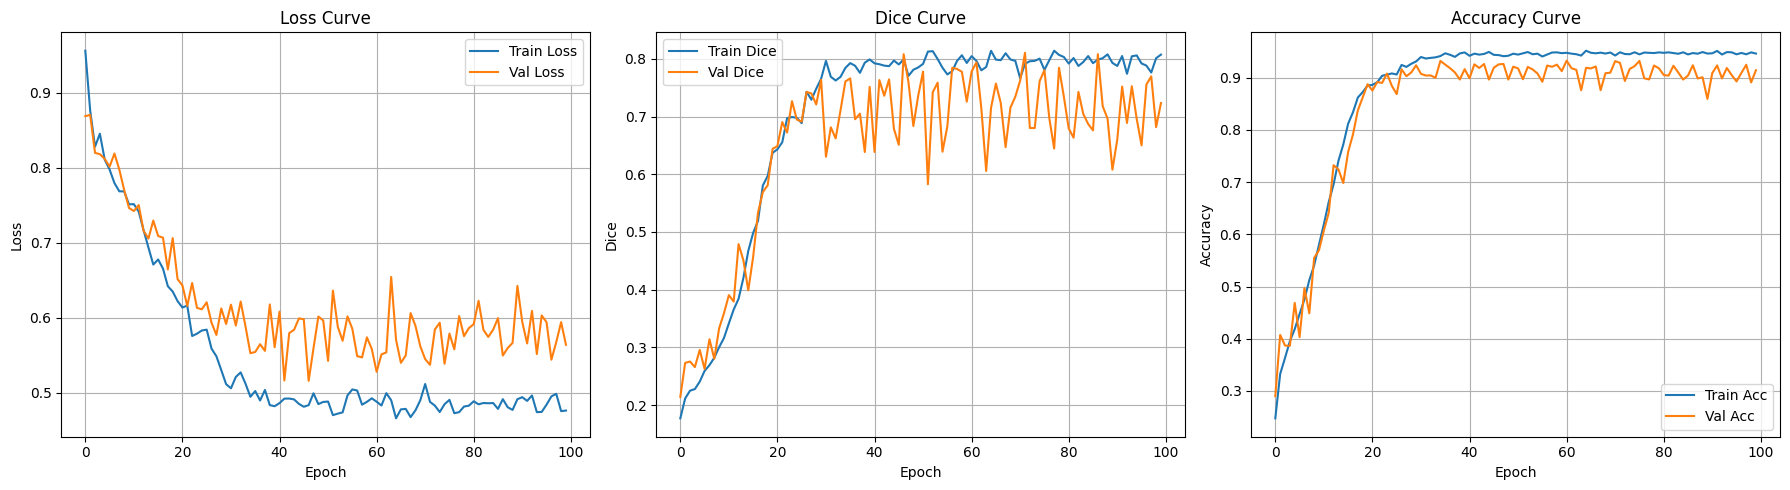


✅ Training completed!
📁 Best models saved: best_modelsax6_fixed.pth and best_model_rv6.pth


In [1]:
# ============================================
# 🔹 Imports
# ============================================

import os, gc, warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True


# ============================================
# 🔹 Paths
# ============================================

BASE_PATH = r"D:\CMR-MULTI\CINE_MULTI"

TRAIN_IMAGE_PATH = os.path.join(BASE_PATH, "SAX_TR", "image")
TRAIN_MASK_PATH  = os.path.join(BASE_PATH, "SAX_TR", "anno")

VAL_IMAGE_PATH   = os.path.join(BASE_PATH, "SAX_VAL", "image")
VAL_MASK_PATH    = os.path.join(BASE_PATH, "SAX_VAL", "anno")

NUM_CLASSES = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================
# 🔹 Dataset 
# ============================================

class NiftiDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted(os.listdir(img_dir))
        
        # Classify files based on RV presence
        self.files_with_rv = []
        self.files_without_rv = []
        
        print("📂 Analyzing files...")
        for f in self.files:
            mask_path = os.path.join(mask_dir, f)
            mask_nii = nib.load(mask_path).dataobj
            sample = np.array(mask_nii[:, :, :5])  # First 5 slices only
            if np.any(sample == 3):
                self.files_with_rv.append(f)
            else:
                self.files_without_rv.append(f)
        
        print(f"✅ Files with RV: {len(self.files_with_rv)}")
        print(f"✅ Files without RV: {len(self.files_without_rv)}")
        
        # If no non-RV files, use all files for both categories
        if len(self.files_without_rv) == 0:
            self.files_without_rv = self.files_with_rv.copy()
        
        # Double dataset length for balanced sampling
        self.total_len = len(self.files) * 2
    
    def __len__(self):
        return self.total_len
    
    def __getitem__(self, idx):
        T = 15
        
        
        if np.random.rand() < 0.5 and len(self.files_with_rv) > 0:
            f = np.random.choice(self.files_with_rv)
        else:
            f = np.random.choice(self.files_without_rv)
        
        img_nii = nib.load(os.path.join(self.img_dir, f)).dataobj
        mask_nii = nib.load(os.path.join(self.mask_dir, f)).dataobj
        depth = img_nii.shape[2]
        
        # Random slice selection (no bias)
        if depth <= T:
            start = 0
        else:
            start = np.random.randint(0, depth - T)
        
        imgs = []
        masks = []
        
        for i in range(start, start + T):
            img = np.array(img_nii[:, :, i], dtype=np.float32)
            mask = np.array(mask_nii[:, :, i], dtype=np.int64)
            
            # Normalization
            if img.max() > img.min():
                img = (img - img.min()) / (img.max() - img.min())
            
            img = torch.tensor(img).unsqueeze(0)
            mask = torch.tensor(mask)
            
            img = F.interpolate(
                img.unsqueeze(0),
                size=(256, 256),
                mode="bilinear",
                align_corners=False
            ).squeeze(0)
            
            mask = F.interpolate(
                mask.unsqueeze(0).unsqueeze(0).float(),
                size=(256, 256),
                mode="nearest"
            ).squeeze().long()
            
            imgs.append(img)
            masks.append(mask)
        
        imgs = torch.stack(imgs)
        masks = torch.stack(masks)
        
        return imgs, masks


# ============================================
# 🔹 SPLIT + DATALOADER 
# ============================================

train_ds = NiftiDataset(TRAIN_IMAGE_PATH, TRAIN_MASK_PATH)
val_ds   = NiftiDataset(VAL_IMAGE_PATH, VAL_MASK_PATH)

train_size = int(0.75 * len(train_ds))
test_size  = len(train_ds) - train_size

train_data, test_data = random_split(train_ds, [train_size, test_size])

train_loader = DataLoader(
    train_data,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=2,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=2,
    num_workers=0
)


# ============================================
# 🔹 Model (UNet + ConvLSTM)
# ============================================

class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hidden_ch):
        super().__init__()
        self.hidden_ch = hidden_ch
        self.conv = nn.Conv2d(in_ch + hidden_ch, 4 * hidden_ch, 3, padding=1)
    
    def forward(self, x, state):
        h, c = state
        
        if h is None:
            b, _, h_, w_ = x.shape
            h = torch.zeros(b, self.hidden_ch, h_, w_, device=x.device)
            c = torch.zeros_like(h)
        
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        
        c = f * c + i * g
        h = o * torch.tanh(c)
        
        return h, c
    
    def init_state(self, b, size):
        h = torch.zeros(b, self.hidden_ch, size[0], size[1], device=next(self.parameters()).device)
        c = torch.zeros_like(h)
        return h, c


class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.net(x)


class UNetConvLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.enc1 = DoubleConv(1, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        
        self.pool = nn.MaxPool2d(2)
        
        self.lstm = ConvLSTMCell(128, 128)
        
        self.up2 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec2 = DoubleConv(128, 64)
        
        self.up1 = nn.ConvTranspose2d(64, 32, 2, 2)
        self.dec1 = DoubleConv(64, 32)
        
        self.out = nn.Conv2d(32, NUM_CLASSES, 1)
    
    def forward(self, x):
        x = x.unsqueeze(1) if x.dim() == 4 else x
        
        B, T, C, H, W = x.shape
        
        outs = []
        h, c = None, None
        
        for t in range(T):
            xt = x[:, t]
            
            e1 = self.enc1(xt)
            e2 = self.enc2(self.pool(e1))
            e3 = self.enc3(self.pool(e2))
            
            if h is None:
                h, c = self.lstm.init_state(B, (e3.shape[2], e3.shape[3]))
            
            h, c = self.lstm(e3, (h, c))
            
            d2 = self.up2(h)
            d2 = self.dec2(torch.cat([d2, e2], dim=1))
            
            d1 = self.up1(d2)
            d1 = self.dec1(torch.cat([d1, e1], dim=1))
            
            outs.append(self.out(d1))
        
        return torch.stack(outs, dim=1)


# ============================================
# 🔹 LOSS FUNCTIONS (Fixed - No Double Weights)
# ============================================

# Class weights for CrossEntropyLoss
weights = torch.tensor([0.05, 1.0, 1.2, 2.0]).to(device)
ce = nn.CrossEntropyLoss(weight=weights)


class DiceLoss(nn.Module):
    def forward(self, pred, target):
        B, T, H, W = target.shape
        pred = torch.softmax(pred, dim=2)
        pred = pred.view(B * T, NUM_CLASSES, H, W)
        target = target.view(B * T, H, W)
        target = F.one_hot(target, NUM_CLASSES).permute(0, 3, 1, 2).float()
        
        inter = (pred * target).sum((2, 3))
        union = pred.sum((2, 3)) + target.sum((2, 3))
        dice = (2 * inter + 1e-6) / (union + 1e-6)
        
        return 1 - dice.mean()


def loss_fn(pred, target):
    ce_loss = ce(pred.view(-1, NUM_CLASSES), target.view(-1))
    dice_loss = DiceLoss()(pred, target)
    return 0.5 * ce_loss + 0.5 * dice_loss


# ============================================
# 🔹 METRICS
# ============================================

def dice_score(pred, target):
    """Returns average Dice score across all classes (like original)"""
    if pred.dim() == 5:
        pred = torch.argmax(pred, dim=2)
    else:
        pred = torch.argmax(pred, dim=1)
    
    pred = pred.reshape(-1, pred.shape[-2], pred.shape[-1])
    target = target.reshape(-1, target.shape[-2], target.shape[-1])
    
    dice = 0
    for c in range(NUM_CLASSES):
        p = (pred == c).float()
        t = (target == c).float()
        dice += (2 * (p * t).sum() + 1e-6) / (p.sum() + t.sum() + 1e-6)
    
    return dice / NUM_CLASSES


def accuracy(pred, target):
    """Returns average accuracy across all classes (like original)"""
    if pred.dim() == 5:
        pred = torch.argmax(pred, dim=2)
    else:
        pred = torch.argmax(pred, dim=1)
    
    pred = pred.reshape(-1, pred.shape[-2], pred.shape[-1])
    target = target.reshape(-1, target.shape[-2], target.shape[-1])
    
    return (pred == target).float().mean()


def rv_dice(pred, target):
    """Returns Dice score for RV class only"""
    pred = torch.argmax(pred, dim=2)
    pred = (pred == 3).float()
    target = (target == 3).float()
    inter = (pred * target).sum()
    union = pred.sum() + target.sum()
    return ((2 * inter + 1e-6) / (union + 1e-6)).item()


# ============================================
# 🔥 MODEL + OPTIMIZER + SCHEDULER
# ============================================

model = UNetConvLSTM().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)


# ============================================
# 🔹 HISTORY LISTS
# ============================================

train_loss_l, val_loss_l = [], []
train_dice_l, val_dice_l = [], []
train_acc_l, val_acc_l = [], []


# ============================================
# 🔹 TRAIN LOOP (WITH PRINTING LIKE THE ORIGINAL)
# ============================================

best = 0
best_rv = 0

for epoch in range(100):
    model.train()
    tl = td = ta = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()
        
        tl += loss.item()
        td += dice_score(out, y).item()
        ta += accuracy(out, y).item()
    
    model.eval()
    vl = vd = va = 0
    rvd = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = loss_fn(out, y)
            
            vl += loss.item()
            vd += dice_score(out, y).item()
            va += accuracy(out, y).item()
            rvd += rv_dice(out, y)
    
    tl /= len(train_loader)
    vl /= len(val_loader)
    td /= len(train_loader)
    vd /= len(val_loader)
    ta /= len(train_loader)
    va /= len(val_loader)
    rvd /= len(val_loader)
    
    scheduler.step(vl)
    
    train_loss_l.append(tl)
    val_loss_l.append(vl)
    train_dice_l.append(td)
    val_dice_l.append(vd)
    train_acc_l.append(ta)
    val_acc_l.append(va)
    
    
    print(f"""
Epoch {epoch+1}
Train Loss {tl:.4f} | Dice {td:.4f} | Acc {ta:.4f}
Val   Loss {vl:.4f} | Dice {vd:.4f} | Acc {va:.4f}
""")
    
    # Save best model based on overall dice
    if vd > best:
        best = vd
        torch.save(model.state_dict(), "best_modelsax6_fixed.pth")
    
    # Save best model based on RV dice
    if rvd > best_rv:
        best_rv = rvd
        torch.save(model.state_dict(), "best_model_rv6.pth")
    
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict()
    }, "checkpointsax6_fixed.pth")


# ============================================
# 🔹 CLASSIFICATION REPORT ON TEST SET
# ============================================

print("\n" + "="*60)
print("🔍 Classification Report on Test Set")
print("="*60)

all_p, all_t = [], []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        p = torch.argmax(out, dim=2)
        
        all_p.extend(p.cpu().reshape(-1).numpy())
        all_t.extend(y.reshape(-1).numpy())

print(classification_report(all_t, all_p,
      target_names=["BG", "LV", "MYO", "RV"]))


# ============================================
# 🔹 PLOTS (Loss / Dice / Accuracy)
# ============================================

plt.figure(figsize=(18, 5))

# Loss plot
plt.subplot(1, 3, 1)
plt.plot(train_loss_l, label="Train Loss")
plt.plot(val_loss_l, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# Dice plot
plt.subplot(1, 3, 2)
plt.plot(train_dice_l, label="Train Dice")
plt.plot(val_dice_l, label="Val Dice")
plt.title("Dice Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.grid()

# Accuracy plot
plt.subplot(1, 3, 3)
plt.plot(train_acc_l, label="Train Acc")
plt.plot(val_acc_l, label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

print("\n✅ Training completed!")
print("📁 Best models saved: best_modelsax6_fixed.pth and best_model_rv6.pth")

In [2]:
# ============================================
# 🔹 TEST EVALUATION
# ============================================

model.load_state_dict(torch.load("best_modelsax6_fixed.pth"))
model.eval()

test_loss = 0
test_dice = 0
test_acc  = 0

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        out = model(x)

        loss = loss_fn(out, y)

        test_loss += loss.item()
        test_dice += dice_score(out, y).item()
        test_acc  += accuracy(out, y).item()

n = len(test_loader)

test_loss /= n
test_dice /= n
test_acc  /= n

print("\n========== TEST RESULTS ==========")
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test Acc  : {test_acc:.4f}")


========== TEST RESULTS ==========
Test Loss : 0.5042
Test Dice : 0.7669
Test Acc  : 0.9417


In [3]:


# ============================================
# 🔹 IMPORTS FOR VIDEO
# ============================================

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
# ============================================
# 🔹 LOAD BEST MODEL
# ============================================

model = UNetConvLSTM().to(device)

model.load_state_dict(
    torch.load(
       "best_modelsax6_fixed.pth",
        map_location=device
    )
)

model.eval()


# ============================================
# 🔹 GET ONE CASE FROM TEST SET
# ============================================

sample_id = 0

x, y = next(iter(test_loader))

with torch.no_grad():

    out = model(
        x.to(device)
    )

pred = torch.argmax(
    out,
    dim=2
).cpu()

x = x.cpu()


# ============================================
# 🔹 PRINT FILE NAME
# ============================================

real_idx = test_data.indices[sample_id]

print(
    "Test File :",
    train_ds.files[real_idx]
)





# ============================================
# 🔹 COLORS 
# ============================================

cmap = ListedColormap([
    "black",      # 0 Background
    "red",        # 1 LV
    "green",      # 2 MYO
    "blue",       # 3 RV
    
])


# ============================================
# 🔹 LEGEND
# ============================================

legend_handles = [

    mpatches.Patch(
        color='black',
        label='Background'
    ),

    mpatches.Patch(
        color='red',
        label='LV'
    ),

    mpatches.Patch(
        color='green',
        label='MYO'
    ),

    mpatches.Patch(
        color='blue',
        label='RV'
    )
   
]


# ============================================
# 🔹 FIGURE
# ============================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=6,
    fontsize=10
)


# ============================================
# 🔹 WHICH SAMPLE INSIDE BATCH
# ============================================

sample = 0


# ============================================
# 🔹 ANIMATION FUNCTION
# ============================================

def update(frame):

    for a in ax:
        a.clear()

    # --------------------
    # Input Image
    # --------------------

    ax[0].imshow(
        x[sample, frame, 0].numpy(),
        cmap="gray"
    )

    ax[0].set_title(
        f"Input Frame {frame+1}"
    )

    # --------------------
    # Ground Truth
    # --------------------

    ax[1].imshow(
        y[sample, frame].numpy(),
        cmap=cmap,
        vmin=0,
        vmax=NUM_CLASSES-1
    )

    ax[1].set_title(
        "Ground Truth"
    )

    # --------------------
    # Prediction
    # --------------------

    ax[2].imshow(
        pred[sample, frame].numpy(),
        cmap=cmap,
        vmin=0,
        vmax=NUM_CLASSES-1
    )

    ax[2].set_title(
        "Prediction"
    )

    for a in ax:
        a.axis("off")


# ============================================
# 🔹 CREATE VIDEO
# ============================================

ani = FuncAnimation(
    fig,
    update,
    frames=x.shape[1],
    interval=300,
    repeat=True
)

plt.tight_layout(
    rect=[0,0.08,1,1]
)

plt.close()


# ============================================
# 🔹 SHOW VIDEO
# ============================================

HTML(
    ani.to_jshtml()
)





Test File : CINE_SAX_071.nii.gz


In [ ]:
2ch


Epoch 1
Train Loss 0.9110 | Dice 0.3145 | Acc 0.3376
Val   Loss 0.8681 | Dice 0.4713 | Acc 0.5301


Epoch 2
Train Loss 0.8769 | Dice 0.4589 | Acc 0.5420
Val   Loss 0.8517 | Dice 0.5393 | Acc 0.6608


Epoch 3
Train Loss 0.8484 | Dice 0.5648 | Acc 0.7075
Val   Loss 0.8314 | Dice 0.6264 | Acc 0.7927


Epoch 4
Train Loss 0.8353 | Dice 0.6007 | Acc 0.7483
Val   Loss 0.8235 | Dice 0.6183 | Acc 0.7375


Epoch 5
Train Loss 0.8215 | Dice 0.6276 | Acc 0.7673
Val   Loss 0.8026 | Dice 0.6564 | Acc 0.7754


Epoch 6
Train Loss 0.8117 | Dice 0.6430 | Acc 0.7834
Val   Loss 0.8021 | Dice 0.6773 | Acc 0.8135


Epoch 7
Train Loss 0.7998 | Dice 0.6675 | Acc 0.8041
Val   Loss 0.7920 | Dice 0.6800 | Acc 0.8181


Epoch 8
Train Loss 0.7909 | Dice 0.6736 | Acc 0.8105
Val   Loss 0.7751 | Dice 0.7196 | Acc 0.8537


Epoch 9
Train Loss 0.7801 | Dice 0.6995 | Acc 0.8333
Val   Loss 0.7758 | Dice 0.7014 | Acc 0.8230


Epoch 10
Train Loss 0.7741 | Dice 0.6981 | Acc 0.8337
Val   Loss 0.7694 | Dice 0.6983 | Acc 0.8345


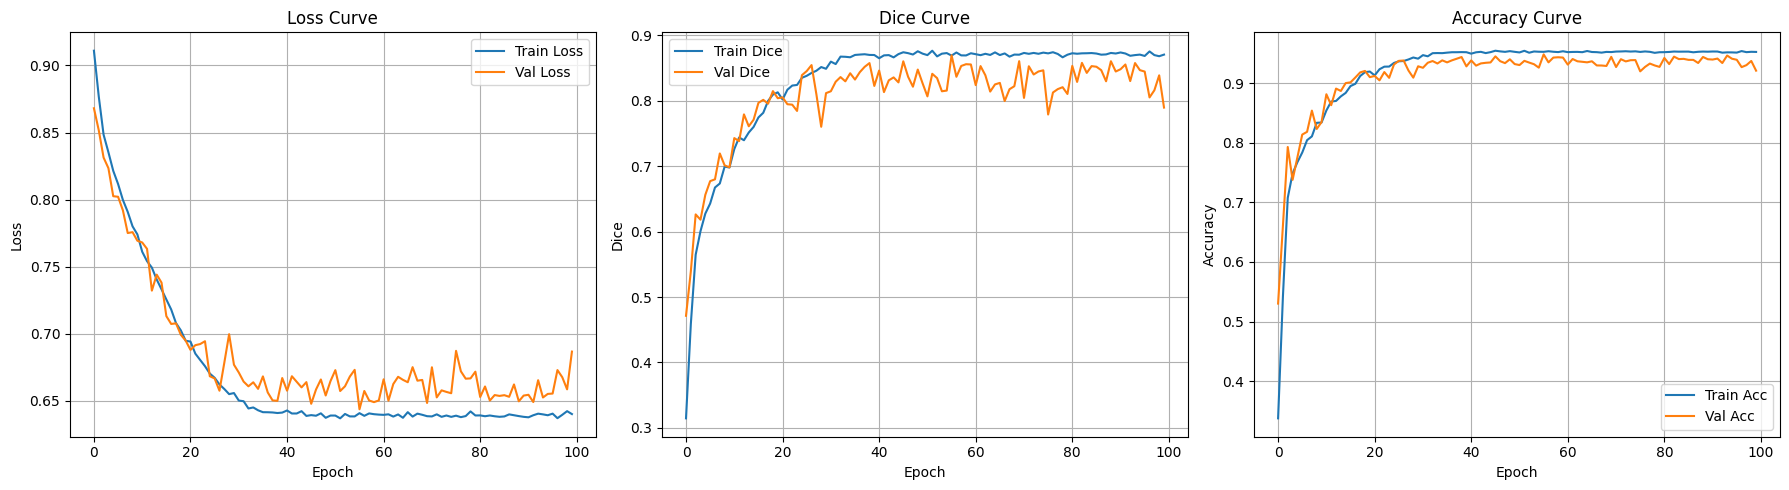

In [25]:
# ============================================
# 🔹 Imports
# ============================================

import os, gc, warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True


# ============================================
# 🔹 Paths
# ============================================

BASE_PATH = r"D:\CMR-MULTI\CINE_MULTI"

TRAIN_IMAGE_PATH = os.path.join(BASE_PATH,"2CH_TR","image")
TRAIN_MASK_PATH  = os.path.join(BASE_PATH,"2CH_TR","anno")

VAL_IMAGE_PATH   = os.path.join(BASE_PATH,"2CH_VAL","image")
VAL_MASK_PATH    = os.path.join(BASE_PATH,"2CH_VAL","anno")

NUM_CLASSES = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================
# 🔹 Dataset 
# ============================================

class NiftiDataset(Dataset):

    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        f = self.files[idx]

        img_nii = nib.load(os.path.join(self.img_dir, f)).dataobj
        mask_nii = nib.load(os.path.join(self.mask_dir, f)).dataobj

        depth = img_nii.shape[2]
        T = 15

        start = 0 if depth <= T else np.random.randint(0, depth - T)

        imgs, masks = [], []

        for i in range(start, start + T):

            img = np.array(img_nii[:, :, i], dtype=np.float32)
            mask = np.array(mask_nii[:, :, i], dtype=np.int64)

            if img.max() > img.min():
                img = (img - img.min()) / (img.max() - img.min())

            img = torch.tensor(img).unsqueeze(0)
            mask = torch.tensor(mask)

            img = F.interpolate(img.unsqueeze(0),(256,256),mode='bilinear').squeeze(0)
            mask = F.interpolate(mask.unsqueeze(0).unsqueeze(0).float(),
                                 (256,256),
                                 mode='nearest').squeeze().long()

            imgs.append(img)
            masks.append(mask)

        return torch.stack(imgs), torch.stack(masks)


# ============================================
# 🔹 SPLIT + DATALOADER 
# ============================================

train_ds = NiftiDataset(TRAIN_IMAGE_PATH, TRAIN_MASK_PATH)
val_ds   = NiftiDataset(VAL_IMAGE_PATH, VAL_MASK_PATH)

train_size = int(0.75 * len(train_ds))
test_size  = len(train_ds) - train_size

train_data, test_data = random_split(train_ds,[train_size,test_size])


train_loader = DataLoader(
    train_data,
    batch_size=2,
    shuffle=True,
    num_workers=0,   
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=2,
    num_workers=0,   
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=2,
    num_workers=0
)


# ============================================
# 🔹 Model 
# ============================================

class ConvLSTMCell(nn.Module):
    def __init__(self,in_ch,hidden_ch):
        super().__init__()
        self.hidden_ch = hidden_ch
        self.conv = nn.Conv2d(in_ch+hidden_ch,4*hidden_ch,3,padding=1)

    def forward(self,x,state):
        h,c = state

        if h is None:
            b,_,h_,w_ = x.shape
            h = torch.zeros(b,self.hidden_ch,h_,w_,device=x.device)
            c = torch.zeros_like(h)

        gates = self.conv(torch.cat([x,h],dim=1))
        i,f,o,g = torch.chunk(gates,4,dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)

        c = f*c + i*g
        h = o*torch.tanh(c)

        return h,c

    def init_state(self,b,size):
        h = torch.zeros(b,self.hidden_ch,size[0],size[1],device=next(self.parameters()).device)
        c = torch.zeros_like(h)
        return h,c


class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.net(x)


class UNetConvLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1,32)
        self.enc2 = DoubleConv(32,64)
        self.enc3 = DoubleConv(64,128)

        self.pool = nn.MaxPool2d(2)

        self.lstm = ConvLSTMCell(128,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = DoubleConv(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = DoubleConv(64,32)

        self.out = nn.Conv2d(32,NUM_CLASSES,1)

    def forward(self,x):

        x = x.unsqueeze(1) if x.dim()==4 else x

        B,T,C,H,W = x.shape

        outs=[]
        h,c=None,None

        for t in range(T):

            xt = x[:,t]

            e1 = self.enc1(xt)
            e2 = self.enc2(self.pool(e1))
            e3 = self.enc3(self.pool(e2))

            if h is None:
                h,c = self.lstm.init_state(B,(e3.shape[2],e3.shape[3]))

            h,c = self.lstm(e3,(h,c))

            d2 = self.up2(h)
            d2 = self.dec2(torch.cat([d2,e2],dim=1))

            d1 = self.up1(d2)
            d1 = self.dec1(torch.cat([d1,e1],dim=1))

            outs.append(self.out(d1))

        return torch.stack(outs,dim=1)


# ============================================
# 🔹 LOSS
# ============================================

ce = nn.CrossEntropyLoss()

class DiceLoss(nn.Module):
    def forward(self,pred,target):

        B,T,H,W = target.shape

        pred = torch.softmax(pred,dim=2)

        pred = pred.view(B*T,NUM_CLASSES,H,W)
        target = target.view(B*T,H,W)

        target = F.one_hot(target,NUM_CLASSES).permute(0,3,1,2).float()

        inter = (pred*target).sum((2,3))
        union = pred.sum((2,3)) + target.sum((2,3))

        return 1 - ((2*inter+1e-6)/(union+1e-6)).mean()


def loss_fn(pred,target):
    return 0.5*ce(pred.view(-1,NUM_CLASSES),target.view(-1)) + 0.5*DiceLoss()(pred,target)


# ============================================
# 🔹 METRICS
# ============================================

def dice_score(pred,target):

    if pred.dim()==5:
        pred = torch.argmax(pred,dim=2)
    else:
        pred = torch.argmax(pred,dim=1)

    pred = pred.reshape(-1,pred.shape[-2],pred.shape[-1])
    target = target.reshape(-1,target.shape[-2],target.shape[-1])

    dice=0
    for c in range(NUM_CLASSES):
        p = (pred==c).float()
        t = (target==c).float()
        dice += (2*(p*t).sum()+1e-6)/(p.sum()+t.sum()+1e-6)

    return dice/NUM_CLASSES


def accuracy(pred,target):

    if pred.dim()==5:
        pred = torch.argmax(pred,dim=2)
    else:
        pred = torch.argmax(pred,dim=1)

    pred = pred.reshape(-1,pred.shape[-2],pred.shape[-1])
    target = target.reshape(-1,target.shape[-2],target.shape[-1])

    return (pred==target).float().mean()


# ============================================
# 🔥 MODEL + OPTIMIZER + SCHEDULER
# ============================================

model = UNetConvLSTM().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)


# ============================================
# 🔹 HISTORY 
# ============================================

train_loss_l, val_loss_l = [], []
train_dice_l, val_dice_l = [], []
train_acc_l, val_acc_l = [], []


# ============================================
# 🔹 TRAIN LOOP
# ============================================

best = 0

for epoch in range(100):

    model.train()
    tl=td=ta=0

    for x,y in train_loader:
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out,y)
        loss.backward()
        optimizer.step()

        tl += loss.item()
        td += dice_score(out,y).item()
        ta += accuracy(out,y).item()

    model.eval()
    vl=vd=va=0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)

            out = model(x)
            loss = loss_fn(out,y)

            vl += loss.item()
            vd += dice_score(out,y).item()
            va += accuracy(out,y).item()

    tl/=len(train_loader); vl/=len(val_loader)
    td/=len(train_loader); vd/=len(val_loader)
    ta/=len(train_loader); va/=len(val_loader)

    scheduler.step(vl)

    train_loss_l.append(tl)
    val_loss_l.append(vl)
    train_dice_l.append(td)
    val_dice_l.append(vd)
    train_acc_l.append(ta)
    val_acc_l.append(va)

    print(f"""
Epoch {epoch+1}
Train Loss {tl:.4f} | Dice {td:.4f} | Acc {ta:.4f}
Val   Loss {vl:.4f} | Dice {vd:.4f} | Acc {va:.4f}
""")

    if vd > best:
        best = vd
        torch.save(model.state_dict(),"best_model2ch1.pth")

    torch.save({
        "epoch":epoch,
        "model":model.state_dict(),
        "optimizer":optimizer.state_dict()
    },"checkpoint2ch1.pth")


# ============================================
# 🔹 CLASSIFICATION REPORT
# ============================================

all_p,all_t=[],[]

model.eval()

with torch.no_grad():
    for x,y in test_loader:
        x=x.to(device)
        out=model(x)
        p=torch.argmax(out,dim=2)

        all_p.extend(p.cpu().reshape(-1).numpy())
        all_t.extend(y.reshape(-1).numpy())

print(classification_report(all_t,all_p,
      target_names=["BG","LV","MYO"]))
# ============================================
# 🔹 PLOTS (Loss / Dice / Accuracy)
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))

# ---------------- LOSS ----------------
plt.subplot(1,3,1)
plt.plot(train_loss_l, label="Train Loss")
plt.plot(val_loss_l, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# ---------------- DICE ----------------
plt.subplot(1,3,2)
plt.plot(train_dice_l, label="Train Dice")
plt.plot(val_dice_l, label="Val Dice")
plt.title("Dice Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.grid()

# ---------------- ACC ----------------
plt.subplot(1,3,3)
plt.plot(train_acc_l, label="Train Acc")
plt.plot(val_acc_l, label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [26]:
# ============================================
# 🔹 TEST EVALUATION
# ============================================

model.load_state_dict(torch.load("best_model2ch1.pth"))
model.eval()

test_loss = 0
test_dice = 0
test_acc  = 0

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device)

        out = model(x)

        loss = loss_fn(out, y)

        test_loss += loss.item()
        test_dice += dice_score(out, y).item()
        test_acc  += accuracy(out, y).item()

n = len(test_loader)

test_loss /= n
test_dice /= n
test_acc  /= n

print("\n========== TEST RESULTS ==========")
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Dice : {test_dice:.4f}")
print(f"Test Acc  : {test_acc:.4f}")


========== TEST RESULTS ==========
Test Loss : 0.6634
Test Dice : 0.8414
Test Acc  : 0.9426


In [9]:
# ============================================
# 🔹 Imports
# ============================================

import os, gc, warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True


# ============================================
# 🔹 Paths
# ============================================

BASE_PATH = r"D:\CMR-MULTI\CINE_MULTI"

TRAIN_IMAGE_PATH = os.path.join(BASE_PATH,"2CH_TR","image")
TRAIN_MASK_PATH  = os.path.join(BASE_PATH,"2CH_TR","anno")

VAL_IMAGE_PATH   = os.path.join(BASE_PATH,"2CH_VAL","image")
VAL_MASK_PATH    = os.path.join(BASE_PATH,"2CH_VAL","anno")

NUM_CLASSES = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================
# 🔹 Dataset 
# ============================================

class NiftiDataset(Dataset):

    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        f = self.files[idx]

        img_nii = nib.load(os.path.join(self.img_dir, f)).dataobj
        mask_nii = nib.load(os.path.join(self.mask_dir, f)).dataobj

        depth = img_nii.shape[2]
        T = 15

        start = 0 if depth <= T else np.random.randint(0, depth - T)

        imgs, masks = [], []

        for i in range(start, start + T):

            img = np.array(img_nii[:, :, i], dtype=np.float32)
            mask = np.array(mask_nii[:, :, i], dtype=np.int64)

            if img.max() > img.min():
                img = (img - img.min()) / (img.max() - img.min())

            img = torch.tensor(img).unsqueeze(0)
            mask = torch.tensor(mask)

            img = F.interpolate(img.unsqueeze(0),(256,256),mode='bilinear').squeeze(0)
            mask = F.interpolate(mask.unsqueeze(0).unsqueeze(0).float(),
                                 (256,256),
                                 mode='nearest').squeeze().long()

            imgs.append(img)
            masks.append(mask)

        return torch.stack(imgs), torch.stack(masks)


# ============================================
# 🔹 SPLIT + DATALOADER 
# ============================================

train_ds = NiftiDataset(TRAIN_IMAGE_PATH, TRAIN_MASK_PATH)
val_ds   = NiftiDataset(VAL_IMAGE_PATH, VAL_MASK_PATH)

train_size = int(0.75 * len(train_ds))
test_size  = len(train_ds) - train_size

train_data, test_data = random_split(train_ds,[train_size,test_size])


train_loader = DataLoader(
    train_data,
    batch_size=2,
    shuffle=True,
    num_workers=0,   
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=2,
    num_workers=0,   
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=2,
    num_workers=0
)


# ============================================
# 🔹 Model
# ============================================

class ConvLSTMCell(nn.Module):
    def __init__(self,in_ch,hidden_ch):
        super().__init__()
        self.hidden_ch = hidden_ch
        self.conv = nn.Conv2d(in_ch+hidden_ch,4*hidden_ch,3,padding=1)

    def forward(self,x,state):
        h,c = state

        if h is None:
            b,_,h_,w_ = x.shape
            h = torch.zeros(b,self.hidden_ch,h_,w_,device=x.device)
            c = torch.zeros_like(h)

        gates = self.conv(torch.cat([x,h],dim=1))
        i,f,o,g = torch.chunk(gates,4,dim=1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)

        c = f*c + i*g
        h = o*torch.tanh(c)

        return h,c

    def init_state(self,b,size):
        h = torch.zeros(b,self.hidden_ch,size[0],size[1],device=next(self.parameters()).device)
        c = torch.zeros_like(h)
        return h,c


class DoubleConv(nn.Module):
    def __init__(self,in_c,out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.net(x)


class UNetConvLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1,32)
        self.enc2 = DoubleConv(32,64)
        self.enc3 = DoubleConv(64,128)

        self.pool = nn.MaxPool2d(2)

        self.lstm = ConvLSTMCell(128,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)
        self.dec2 = DoubleConv(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,2)
        self.dec1 = DoubleConv(64,32)

        self.out = nn.Conv2d(32,NUM_CLASSES,1)

    def forward(self,x):

        x = x.unsqueeze(1) if x.dim()==4 else x

        B,T,C,H,W = x.shape

        outs=[]
        h,c=None,None

        for t in range(T):

            xt = x[:,t]

            e1 = self.enc1(xt)
            e2 = self.enc2(self.pool(e1))
            e3 = self.enc3(self.pool(e2))

            if h is None:
                h,c = self.lstm.init_state(B,(e3.shape[2],e3.shape[3]))

            h,c = self.lstm(e3,(h,c))

            d2 = self.up2(h)
            d2 = self.dec2(torch.cat([d2,e2],dim=1))

            d1 = self.up1(d2)
            d1 = self.dec1(torch.cat([d1,e1],dim=1))

            outs.append(self.out(d1))

        return torch.stack(outs,dim=1)


# ============================================

# ============================================
# 🔹 IMPORTS FOR VIDEO
# ============================================

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
# ============================================
# 🔹 LOAD BEST MODEL
# ============================================

model = UNetConvLSTM().to(device)

model.load_state_dict(
    torch.load(
        "best_model2ch1.pth",
        map_location=device
    )
)

model.eval()


# ============================================
# 🔹 GET ONE CASE FROM TEST SET
# ============================================

sample_id = 0

x, y = next(iter(test_loader))

with torch.no_grad():

    out = model(
        x.to(device)
    )

pred = torch.argmax(
    out,
    dim=2
).cpu()

x = x.cpu()


# ============================================
# 🔹 PRINT FILE NAME
# ============================================

real_idx = test_data.indices[sample_id]

print(
    "Test File :",
    train_ds.files[real_idx]
)





# ============================================
# 🔹 COLORS
# ============================================

cmap = ListedColormap([
    "black",      # 0 Background
    "red",        # 1 LV
    "green",      # 2 MYO
    
])


# ============================================
# 🔹 LEGEND
# ============================================

legend_handles = [

    mpatches.Patch(
        color='black',
        label='Background'
    ),

    mpatches.Patch(
        color='red',
        label='LV'
    ),

    mpatches.Patch(
        color='green',
        label='MYO'
    )
]


# ============================================
# 🔹 FIGURE
# ============================================

fig, ax = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=6,
    fontsize=10
)


# ============================================
# 🔹 WHICH SAMPLE INSIDE BATCH
# ============================================

sample = 0


# ============================================
# 🔹 ANIMATION FUNCTION
# ============================================

def update(frame):

    for a in ax:
        a.clear()

    # --------------------
    # Input Image
    # --------------------

    ax[0].imshow(
        x[sample, frame, 0].numpy(),
        cmap="gray"
    )

    ax[0].set_title(
        f"Input Frame {frame+1}"
    )

    # --------------------
    # Ground Truth
    # --------------------

    ax[1].imshow(
        y[sample, frame].numpy(),
        cmap=cmap,
        vmin=0,
        vmax=NUM_CLASSES-1
    )

    ax[1].set_title(
        "Ground Truth"
    )

    # --------------------
    # Prediction
    # --------------------

    ax[2].imshow(
        pred[sample, frame].numpy(),
        cmap=cmap,
        vmin=0,
        vmax=NUM_CLASSES-1
    )

    ax[2].set_title(
        "Prediction"
    )

    for a in ax:
        a.axis("off")


# ============================================
# 🔹 CREATE VIDEO
# ============================================

ani = FuncAnimation(
    fig,
    update,
    frames=x.shape[1],
    interval=300,
    repeat=True
)

plt.tight_layout(
    rect=[0,0.08,1,1]
)

plt.close()


# ============================================
# 🔹 SHOW VIDEO
# ============================================

HTML(
    ani.to_jshtml()
)





Test File : CINE_2CH_028.nii.gz
